<a href="https://colab.research.google.com/github/qaiserxd/machine-learning-scikit-learn/blob/master/mnist_stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load MNIST data from OpenML
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]

# Normalize pixel values
X = X.astype('float32') / 255.0

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

Fetching MNIST dataset...


In [5]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import KFold

# Define the 5 base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)),
    ('hgb', HistGradientBoostingClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('lsvc', LinearSVC(random_state=42, dual=False))
]

# Define KFold cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Initialize Stacking Classifier
stack_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=kf,
    n_jobs=-1
)

#training 5 models
print("\nTraining Stacking Classifier...")
stack_clf.fit(X_train, y_train)  # Using a subset for faster training

# Evaluate the model
y_pred_train = stack_clf.predict(X_train)
train_score = accuracy_score(y_train, y_pred_train)

y_pred = stack_clf.predict(X_test)
test_score = accuracy_score(y_test, y_pred)

print(f"Stacking Ensemble Training Accuracy: {train_score * 100:.2f}%")
print(f"Stacking Ensemble Testing Accuracy: {test_score * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Training Stacking Classifier...
Stacking Ensemble Training Accuracy: 99.96%
Stacking Ensemble Testing Accuracy: 98.27%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       983
           1       0.99      0.99      0.99      1152
           2       0.97      0.99      0.98       967
           3       0.98      0.97      0.98      1034
           4       0.98      0.98      0.98       906
           5       0.99      0.98      0.98       937
           6       0.99      0.99      0.99       961
           7       0.98      0.99      0.98      1055
           8       0.98      0.97      0.98       969
           9       0.97      0.97      0.97      1036

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



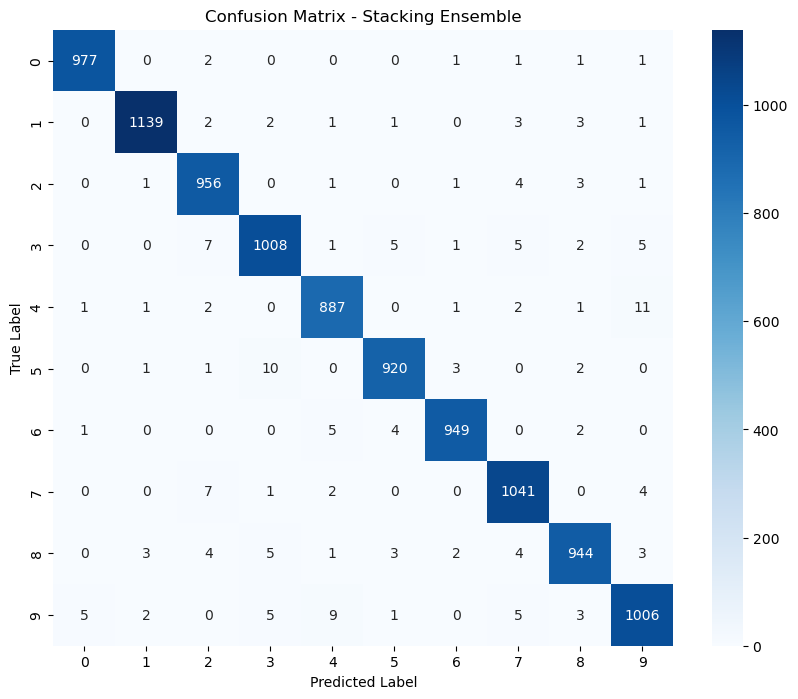

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Visualize the performance with a confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()